In [96]:
!pip install torchview torchviz
# !pip install tensorboardcolab
!pip install -U 'git+https://github.com/facebookresearch/fvcore' #
!pip install ptflops # for FLOPs and MACs calculation.

  Cloning https://github.com/facebookresearch/fvcore to /tmp/pip-req-build-o6u9gqo5
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/fvcore /tmp/pip-req-build-o6u9gqo5
  Resolved https://github.com/facebookresearch/fvcore to commit 9d9285d9cc39723578b3423aa24552926590a0c3
  Preparing metadata (setup.py) ... done


In [97]:
#Basic libraries
import os
import numpy as np
import copy
import random
import matplotlib.pyplot as plt


#Framework
import torch
import torchvision

#data and its management related libraries
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, models, transforms
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter
import torchview #Visualizes the model architecture
from torchviz import make_dot # Visualizes the computation graph, how operations connect, how gradients flow.


from PIL import Image #python imaging library, image handling
# PIL.Image - load images, convert formats, apply basic image operations
import cv2 # OpenCV- image transformations, filtering



#for creating neural networks
import torch.nn as nn # Contains- layers (Linear, Conv2d, etc.)
import torch.nn.functional as F #Provides functional versions of operations: ReLU, softmax, pooling
import torchvision.transforms.functional as TF # Functional image transformations

#for optimising neural networks
import torch.optim as optim

#for metrics and analysis
import sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from torchsummary import summary # Prints a layer-by-layer summary of the model - number of parameters, input/output shapes


#For Computing FLOPs and MACs
import fvcore
from fvcore.nn import FlopCountAnalysis # for FLOPs calculations
from fvcore.nn import flop_count_table # for FLOPs calculations
from ptflops import get_model_complexity_info #another lib for FLOPs and MACs calculation.

<h1>Question 1: Loading the Dataset and splitting</h1>

In [98]:
pip install ucimlrepo

In [99]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
parkinsons_telemonitoring = fetch_ucirepo(id=189)

# data (as pandas dataframes)
X = parkinsons_telemonitoring.data.features
y = parkinsons_telemonitoring.data.targets

# metadata
print(parkinsons_telemonitoring.metadata)

# variable information
print(parkinsons_telemonitoring.variables)


{'uci_id': 189, 'name': 'Parkinsons Telemonitoring', 'repository_url': 'https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring', 'data_url': 'https://archive.ics.uci.edu/static/public/189/data.csv', 'abstract': "Oxford Parkinson's Disease Telemonitoring Dataset", 'area': 'Health and Medicine', 'tasks': ['Regression'], 'characteristics': ['Tabular'], 'num_instances': 5875, 'num_features': 19, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['motor_UPDRS', 'total_UPDRS'], 'index_col': ['subject#'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5ZS3N', 'creators': ['Athanasios Tsanas', 'Max Little'], 'intro_paper': {'ID': 229, 'type': 'NATIVE', 'title': "Accurate Telemonitoring of Parkinson's Disease Progression by Noninvasive Speech Tests", 'authors': 'A. Tsanas, Max A. Little, P. McSharry, L. Ramig', 'venue': 'IEEE Transactions on Bio

In [100]:
X.shape

(5875, 19)

In [101]:
y

,motor_UPDRS,total_UPDRS
0,28.199,34.398
1,28.447,34.894
2,28.695,35.389
3,28.905,35.810
4,29.187,36.375
...,...,...
5870,22.485,33.485
5871,21.988,32.988
5872,21.495,32.495
5873,21.007,32.007


In [102]:
from sklearn.model_selection import train_test_split
X_dash, X_test, y_dash, y_test = train_test_split(X,y,test_size=0.15,random_state=42)

#15/85 = 0.17647

X_train, X_val, y_train, y_val = train_test_split(X_dash,y_dash,test_size=0.17647,random_state=42)

<h1>Question 2: Feature Scaling and PyTorch DataLoaders

In [103]:
#Standard Scaler is used as ReLU activation function will be used

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_val= scaler.transform(X_val)
X_test= scaler.transform(X_test)

In [104]:
#converting sets to tensors

X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

y_train = torch.tensor(y_train.values,dtype=torch.float32)
y_val = torch.tensor(y_val.values,dtype=torch.float32)
y_test = torch.tensor(y_test.values,dtype=torch.float32)

In [105]:
from torch.utils.data import TensorDataset

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

In [106]:
x = 32 #batch_size

train_loader = DataLoader(train_ds, batch_size=x, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=x, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=x, shuffle=False)

<h1>Question 3: Designing Neural Network</h1>

The activation function for the output layer must be linear as for regression, we require the output to be in complete range and not restricted.

In [107]:
class RegressionNN(nn.Module):
    def __init__(self, input_dim, hidden_layers):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden_layers:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h

        layers.append(nn.Linear(prev_dim, 2))  # 2 target variables & linear activation

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


In [108]:
def evaluate_model(hidden_layers, train_loader, val_loader, input_dim, epochs=20, lr=0.01):

    model = RegressionNN(input_dim, hidden_layers)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr)

    # Train for a few epochs (ONLY for architecture comparison)
    for _ in range(epochs):
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

    # Compute validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in val_loader:
            outputs = model(x)
            loss = criterion(outputs, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    return val_loss


In [109]:
input_dim = X_train.shape[1]
#input_dim

#different hidden layer configurations
architectures = {
    "Single hidden layer (32)": [32],
    "Single hidden layer (64)": [64],
    "Single hidden layer (128)": [128],
    "Two hidden layers (128, 64)": [128, 64],
    "Two hidden layers (64, 64)": [64, 64],
    "Two hidden layers (128, 128)": [128, 128],
    "Three hidden layers (256, 128, 64)": [256, 128, 64],
    "Three hidden layers (128, 64, 32)": [128, 64, 32],
    "Rule of Thumb Heuristic": [input_dim*4,input_dim*2,input_dim],
    "Three hidden layers (512, 256, 128)": [128, 64, 32]
}

validation_losses = {}

for name, hidden_layers in architectures.items():
    loss = evaluate_model(
        hidden_layers,
        train_loader,
        val_loader,
        input_dim
    )
    validation_losses[name] = loss
    print(f"{name} → Validation Loss: {loss:.4f}")

Single hidden layer (32) → Validation Loss: 58.2715
Single hidden layer (64) → Validation Loss: 51.7048
Single hidden layer (128) → Validation Loss: 42.0297
Two hidden layers (128, 64) → Validation Loss: 33.9973
Two hidden layers (64, 64) → Validation Loss: 27.9106
Two hidden layers (128, 128) → Validation Loss: 24.6172
Three hidden layers (256, 128, 64) → Validation Loss: 23.7964
Three hidden layers (128, 64, 32) → Validation Loss: 28.1998
Rule of Thumb Heuristic → Validation Loss: 35.3096
Three hidden layers (512, 256, 128) → Validation Loss: 28.0706


On evaluation of multiple architectures, and comparision of validation loss, it is clearly found that the hidden later configuration of **Three Hidden layers: [256,128,64]** gives the least validation loss. Hence, this configuration is selected for the final model.

In [110]:
best_architecture = min(validation_losses, key=validation_losses.get)
print("Selected architecture based on validation loss:", best_architecture)

best_hidden_layers = architectures[best_architecture]

Selected architecture based on validation loss: Three hidden layers (256, 128, 64)


In [111]:
#Loading the final model
finalModel = RegressionNN(input_dim, best_hidden_layers)

<h1>Question 4: Model Summary and FLOPs</h1>

In [112]:
#Model Summary and number of trainable parameters
print(finalModel)

total_params = sum(p.numel() for p in finalModel.parameters() if p.requires_grad)
print("Total number of trainable parameters:", total_params)


RegressionNN(
  (model): Sequential(
    (0): Linear(in_features=19, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)
Total number of trainable parameters: 46402


In [113]:
summary(finalModel, (1,input_dim))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 256]           5,120
              ReLU-2               [-1, 1, 256]               0
            Linear-3               [-1, 1, 128]          32,896
              ReLU-4               [-1, 1, 128]               0
            Linear-5                [-1, 1, 64]           8,256
              ReLU-6                [-1, 1, 64]               0
            Linear-7                 [-1, 1, 2]             130
Total params: 46,402
Trainable params: 46,402
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.18
Estimated Total Size (MB): 0.18
----------------------------------------------------------------


In [114]:
#computing flops
random_tensor=torch.randn(1,input_dim)
flops = FlopCountAnalysis(finalModel, random_tensor)

print('Total FLOPs',flops.total()) # total number of floating-point operations required for one forward pass

print('FLOPs by Operator',flops.by_operator()) # which types of operations are contributing most to the computation.

print('FLOPs by Module',flops.by_module()) # breaks FLOPs down layer by layer.

print('FLOPs by Module and Operator',flops.by_module_and_operator()) # combines: Which layer + Which operation + How many FLOPs

Total FLOPs 45952
FLOPs by Operator Counter({'linear': 45952})
FLOPs by Module Counter({'': 45952, 'model': 45952, 'model.2': 32768, 'model.4': 8192, 'model.0': 4864, 'model.6': 128, 'model.1': 0, 'model.3': 0, 'model.5': 0})
FLOPs by Module and Operator {'': Counter({'linear': 45952}), 'model': Counter({'linear': 45952}), 'model.0': Counter({'linear': 4864}), 'model.1': Counter(), 'model.2': Counter({'linear': 32768}), 'model.3': Counter(), 'model.4': Counter({'linear': 8192}), 'model.5': Counter(), 'model.6': Counter({'linear': 128})}


In [115]:
print(flop_count_table(flops))

| module     | #parameters or shape   | #flops   |
|:-----------|:-----------------------|:---------|
| model      | 46.402K                | 45.952K  |
|  0         |  5.12K                 |  4.864K  |
|   0.weight |   (256, 19)            |          |
|   0.bias   |   (256,)               |          |
|  2         |  32.896K               |  32.768K |
|   2.weight |   (128, 256)           |          |
|   2.bias   |   (128,)               |          |
|  4         |  8.256K                |  8.192K  |
|   4.weight |   (64, 128)            |          |
|   4.bias   |   (64,)                |          |
|  6         |  0.13K                 |  0.128K  |
|   6.weight |   (2, 64)              |          |
|   6.bias   |   (2,)                 |          |


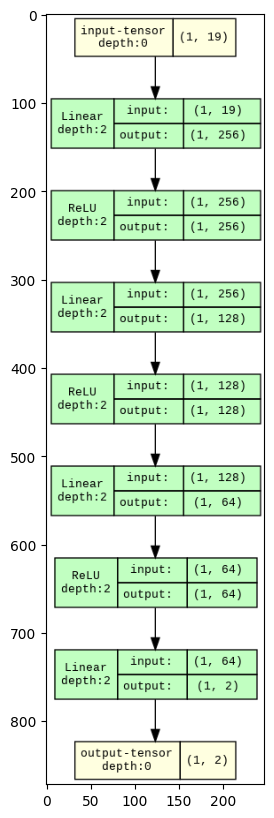

In [116]:
#Visualizing the Network
torchview.draw_graph(finalModel, input_size=(1,input_dim), graph_name="SimpleNN", save_graph=True)
plt.figure(figsize=(5, 10))
plt.imshow(plt.imread('SimpleNN.gv.png'))

Mean Squared Error (MSE) loss is appropriate for this task since the problem involves predicting continuous target variables. MSE penalizes larger prediction errors more strongly and provides a smooth gradient that is well-suited for regression problems.

In [117]:
loss_function = nn.MSELoss()

<h1>Question 5: Training using SGD</h1>

In [118]:
optimizer = torch.optim.SGD(
    finalModel.parameters(),
    lr=0.0001,
    momentum=0.9
)

In [119]:
#if the validation loss doesnt improve in 5 epochs, then learning rate is reduced by half
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=5,
    factor=0.5,
)

In [120]:
total_epochs = 100
train_losses = []
val_losses = []

best_val_loss = float('inf') #initializing validation loss to infinity

In [121]:
for epoch in range(total_epochs):

    # ---- Training phase ----
    finalModel.train()
    running_train_loss = 0.0

    for x, y in train_loader:
        # x = x.float()
        # y = y.float()

        optimizer.zero_grad()
        outputs = finalModel(x)
        loss = loss_function(outputs, y)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)


    # ---- Validation phase ----
    finalModel.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            # x = x.float()
            # y = y.float()

            outputs = finalModel(x)
            loss = loss_function(outputs, y)
            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)


    # ---- Scheduler step ----
    scheduler.step(val_loss)


    # ---- Save best model (needed for Q6) ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(finalModel.state_dict(), "best_model.pth")


    print(
        f"Epoch [{epoch+1}/{total_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )


Epoch [1/100] | Train Loss: 320.5170 | Val Loss: 82.9466
Epoch [2/100] | Train Loss: 76.7635 | Val Loss: 69.3633
Epoch [3/100] | Train Loss: 69.7577 | Val Loss: 62.4466
Epoch [4/100] | Train Loss: 64.5436 | Val Loss: 60.0657
Epoch [5/100] | Train Loss: 60.3012 | Val Loss: 54.0824
Epoch [6/100] | Train Loss: 54.3024 | Val Loss: 50.8909
Epoch [7/100] | Train Loss: 50.8031 | Val Loss: 50.0883
Epoch [8/100] | Train Loss: 50.0659 | Val Loss: 46.6849
Epoch [9/100] | Train Loss: 44.2190 | Val Loss: 44.2242
Epoch [10/100] | Train Loss: 43.6173 | Val Loss: 47.9537
Epoch [11/100] | Train Loss: 40.8221 | Val Loss: 40.4814
Epoch [12/100] | Train Loss: 37.4347 | Val Loss: 38.4248
Epoch [13/100] | Train Loss: 37.8167 | Val Loss: 36.4597
Epoch [14/100] | Train Loss: 34.4308 | Val Loss: 44.6557
Epoch [15/100] | Train Loss: 35.4443 | Val Loss: 46.2122
Epoch [16/100] | Train Loss: 33.2016 | Val Loss: 33.1065
Epoch [17/100] | Train Loss: 30.8233 | Val Loss: 33.9612
Epoch [18/100] | Train Loss: 28.8007 | 

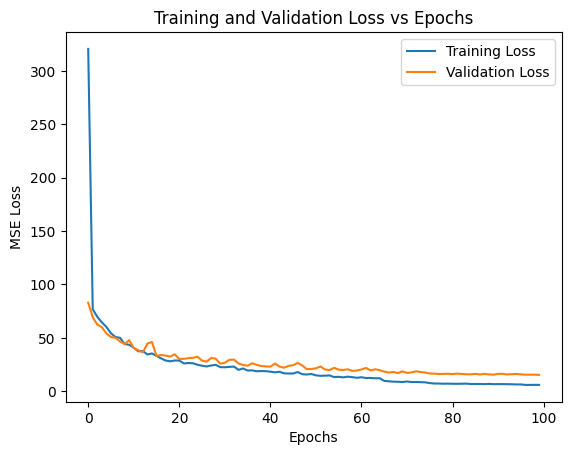

In [122]:

plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss vs Epochs")
plt.legend()
plt.show()


<h1>Question 6: Best Model and Test Prediction</h1>



In [123]:
best_model = RegressionNN(
    input_dim=X_train.shape[1],
    hidden_layers=[256,128,64]
)


In [124]:
#This best model is saved in question 5 training loop and loaded here
best_model.load_state_dict(torch.load("best_model.pth"))
best_model.eval()


RegressionNN(
  (model): Sequential(
    (0): Linear(in_features=19, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [137]:
y_test_true = []
y_test_pred = []

with torch.no_grad():
    for x, y in test_loader:
        outputs = best_model(x)

        y_test_true.append(y)
        y_test_pred.append(outputs)

print(y_test_true[0].shape)

torch.Size([32, 2])


In [138]:
#combining data batches
y_test_true = torch.cat(y_test_true)
y_test_pred = torch.cat(y_test_pred)

print(y_test_true.shape)


torch.Size([882, 2])


<h1>Question 7: Analyzing Model Performance</h1>

In [139]:
best_model.eval()

y_train_true = []
y_train_pred = []

with torch.no_grad():
    for x, y in train_loader:
        x = x.float()
        y = y.float()

        outputs = best_model(x)

        y_train_true.append(y)
        y_train_pred.append(outputs)

y_train_true = torch.cat(y_train_true).cpu().numpy()
y_train_pred = torch.cat(y_train_pred).cpu().numpy()


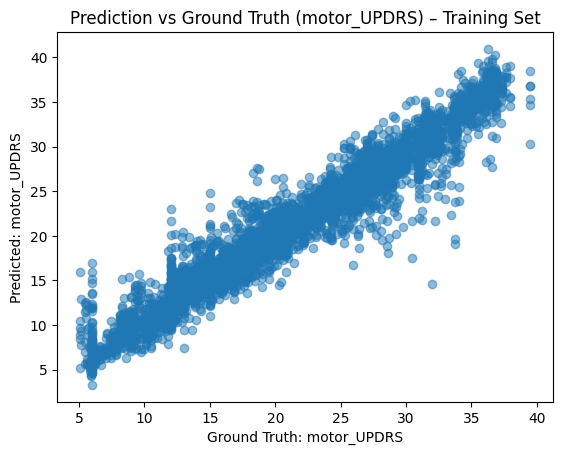

In [140]:

plt.figure()
plt.scatter(y_train_true[:, 0], y_train_pred[:, 0], alpha=0.5)
plt.xlabel("Ground Truth: motor_UPDRS")
plt.ylabel("Predicted: motor_UPDRS")
plt.title("Prediction vs Ground Truth (motor_UPDRS) – Training Set")
plt.show()


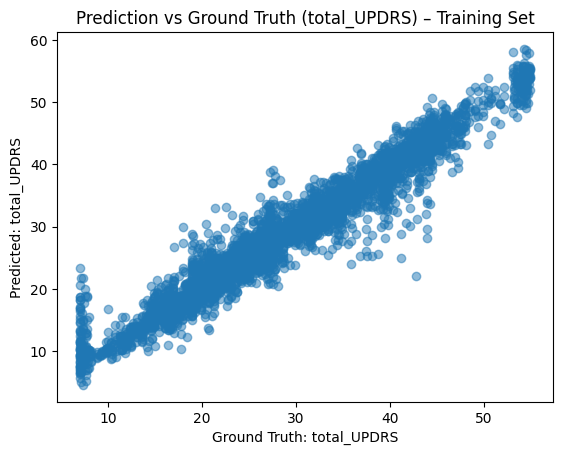

In [141]:
plt.figure()
plt.scatter(y_train_true[:, 1], y_train_pred[:, 1], alpha=0.5)
plt.xlabel("Ground Truth: total_UPDRS")
plt.ylabel("Predicted: total_UPDRS")
plt.title("Prediction vs Ground Truth (total_UPDRS) – Training Set")
plt.show()


In [143]:
from sklearn.metrics import r2_score
r2_motor = r2_score(y_test_true[:, 0], y_test_pred[:, 0])
r2_total = r2_score(y_test_true[:, 1], y_test_pred[:, 1])

print("R² score on test set (motor_UPDRS):", r2_motor)
print("R² score on test set (total_UPDRS):", r2_total)


R² score on test set (motor_UPDRS): 0.8192721074343094
R² score on test set (total_UPDRS): 0.8224855947315398
